# Modelo base LightGBM - Objetivo A

Este notebook entrena un modelo inicial con LightGBM usando las variables generadas para Bolivia. La evaluacion usa metricas tradicionales (`AUC-ROC`, `F1-score`, precision y recall) y resume el desempeno en terminos de fraude detectado y falsos positivos, con una vista especifica para compras presenciales.

## 1) Configuracion

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
target_col = 'is_fraud'


## 2) Carga del dataset de features

El notebook espera el archivo generado por `ingenieria_variables/ing_variables_bolivia_obj_a.ipynb`.

In [2]:
candidate_paths = [
    Path('../data/bolivia_features_obj_a.csv.gz'),
    Path('data/bolivia_features_obj_a.csv.gz'),
]
features_path = next((p for p in candidate_paths if p.exists()), None)
if features_path is None:
    raise FileNotFoundError('No se encontro data/bolivia_features_obj_a.csv.gz. Ejecuta primero el notebook de ingenieria de variables.')

df = pd.read_csv(features_path)
df['tx_datetime'] = pd.to_datetime(df['tx_datetime'], errors='coerce')

if df[target_col].dtype != bool:
    df[target_col] = df[target_col].map(lambda x: str(x).lower() == 'true')

print(f'Ruta usada: {features_path.resolve()}')
print(f'Shape: {df.shape}')
display(df.head())


Ruta usada: C:\Users\josue\uvg\Semestre 9\Security DS\federated-banking-fraud\data\bolivia_features_obj_a.csv.gz
Shape: (100003, 81)


,transaction_id,client_id,tx_datetime,channel,DE60_pos_terminal_type,is_fraud,amount_usd,amount_local,amount_tx_currency,client_baseline_amount,DE4_amount_transaction,DE6_amount_cardholder_billing,DE9_conversion_rate_billing,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE49_currency_code_transaction,DE123_pos_data_code,is_pos_attended,is_card_present_purchase,is_ecom,is_atm,is_moto,is_domestic,is_foreign_currency,is_international_pos,requires_pin,has_emv,amount_usd_log1p,amount_vs_client_baseline,amount_over_baseline_flag,client_txn_count_prev,client_amount_mean_prev,client_amount_median_prev,client_amount_std_prev,amount_zscore_customer,amount_vs_client_mean_prev,amount_vs_client_median_prev,amount_vs_mcc_mean_prev,amount_vs_merchant_mean_prev,time_since_last_txn_min,txn_count_prev_1h,txn_count_prev_6h,txn_count_prev_24h,txn_count_prev_7d,amount_sum_prev_1h,amount_sum_prev_6h,amount_sum_prev_24h,amount_sum_prev_7d,client_merchant_count_prev,is_first_client_merchant,client_mcc_count_prev,is_first_client_mcc,client_currency_count_prev,is_first_client_currency,client_acquirer_country_count_prev,is_first_client_acquirer_country,client_entry_mode_count_prev,is_first_client_entry_mode,channel_fraud_rate_prev_smooth,DE60_pos_terminal_type_fraud_rate_prev_smooth,DE18_merchant_category_code_fraud_rate_prev_smooth,DE22_pos_entry_mode_fraud_rate_prev_smooth,DE25_pos_condition_code_fraud_rate_prev_smooth,currency_tx_alpha_fraud_rate_prev_smooth,hour,day_num,is_weekend,is_night,hour_sin,hour_cos,day_sin,day_cos,client_segment,card_brand,currency_tx_alpha,client_home_city,DE52_pin_data_present,DE55_emv_data_present
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP-CL-00001325,2025-01-01 00:01:51,POS,POS-ATTENDED,False,500.12,3450.82,393.79,2012.51,39379,345082,87630970.0,5651,826,72,1.0,0,826,07200N,True,True,False,False,False,False,True,True,False,False,6.216846,0.248506,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.049189,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PLATINUM,MASTERCARD,GBP,TARIJA,N,N
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP-CL-00000079,2025-01-01 00:03:55,ECOM,ECOM-VIRTUAL,False,1898.93,13102.64,13102.64,1096.46,1310264,1310264,10000000.0,4511,68,81,2.0,59,68,08159N,False,False,True,False,False,True,False,False,False,False,7.549572,1.731873,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.049189,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PRIVATE,VISA,BOB,LAPAZ,N,N
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP-CL-00002344,2025-01-01 00:04:10,ECOM,ECOM-VIRTUAL,False,349.85,2413.94,2413.94,1528.37,241394,241394,10000000.0,5732,68,81,2.0,59,68,08159N,False,False,True,False,False,True,False,False,False,False,5.860359,0.228904,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.048224,0.048224,0.049189,0.048224,0.048224,0.048224,20,1,False,False,-0.866025,0.5,0.781831,0.62349,INFINITE,NaN,BOB,SANTACRUZ,N,N
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP-CL-00002587,2025-01-01 00:04:53,ATM,ATM-UNATTENDED,False,345.58,2384.49,314.16,2483.34,31416,238449,75900496.0,6011,250,51,2.0,0,978,05100Y,False,False,False,True,False,False,True,False,True,True,5.848114,0.139159,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,0,True,0,True,0,True,0,True,0.049189,0.049189,0.049189,0.049189,0.048224,0.049189,20,1,False,False,-0.866025,0.5,0.781831,0.62349,PLATINUM,VISA,EUR,SUCRE,Y,Y
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP-CL-00000087,2025-01-01 00:07:56,POS,POS-ATTENDED,False,118.90,820.38,820.38,1334.55,82038,82038,10000000.0,5812,68,21,3.0,0,68,02100Y,True,True,False,False,False,True,False,False,True,False,4.786658,0.089094,False,0,NaN,Na

## 3) Separación temporal y columnas del modelo

Se usa enero-mayo para entrenamiento y junio para evaluación, respetando el criterio del dataset del proyecto. Las columnas de trazabilidad quedan fuera del entrenamiento.

In [3]:
train_mask = df['tx_datetime'] < pd.Timestamp('2025-06-01')
test_mask = df['tx_datetime'] >= pd.Timestamp('2025-06-01')
pos_eval_mask = df['is_card_present_purchase'].astype(bool)

reference_cols = ['transaction_id', 'client_id', 'tx_datetime', 'channel', 'DE60_pos_terminal_type']
leakage_or_target_cols = reference_cols + [target_col]
feature_cols = [c for c in df.columns if c not in leakage_or_target_cols]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = df[target_col].astype(int)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

split_summary = pd.DataFrame({
    'subset': ['train', 'test', 'test_pos_presencial'],
    'rows': [len(X_train), len(X_test), int((test_mask & pos_eval_mask).sum())],
    'frauds': [int(y_train.sum()), int(y_test.sum()), int(y.loc[test_mask & pos_eval_mask].sum())],
    'fraud_rate_pct': [y_train.mean() * 100, y_test.mean() * 100, y.loc[test_mask & pos_eval_mask].mean() * 100],
})

display(split_summary.round(3))
print(f'Features totales: {len(feature_cols)}')
print(f'Numericas/bool: {len(numeric_cols)}')
print(f'Categoricas: {len(categorical_cols)} -> {categorical_cols}')


,subset,rows,frauds,fraud_rate_pct
0,train,83817,4183,4.991
1,test,16186,736,4.547
2,test_pos_presencial,6440,149,2.314


Features totales: 75
Numericas/bool: 68
Categoricas: 7 -> ['DE123_pos_data_code', 'client_segment', 'card_brand', 'currency_tx_alpha', 'client_home_city', 'DE52_pin_data_present', 'DE55_emv_data_present']


## 4) Pipeline base con LightGBM

El pipeline imputa numericas con mediana, categoricas con moda, codifica categoricas con one-hot y entrena un `LGBMClassifier`. Se usa `class_weight='balanced'` como baseline simple para el desbalance de fraude.

In [4]:
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=True)

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', one_hot),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop',
)

model = LGBMClassifier(
    objective='binary',
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model),
])

clf.fit(X_train, y_train)
print('Modelo base entrenado.')


Modelo base entrenado.


## 5) Evaluacion tradicional: AUC-ROC y F1-score

In [5]:
y_train_proba = clf.predict_proba(X_train)[:, 1]
y_test_proba = clf.predict_proba(X_test)[:, 1]

default_threshold = 0.50
y_test_pred = (y_test_proba >= default_threshold).astype(int)

print('Reporte de clasificacion - Test junio, threshold 0.50')
print(classification_report(y_test, y_test_pred, target_names=['legitima', 'fraude'], digits=4))

metrics_default = pd.DataFrame([{
    'threshold': default_threshold,
    'auc_roc_train': roc_auc_score(y_train, y_train_proba),
    'auc_roc_test': roc_auc_score(y_test, y_test_proba),
    'f1_test': f1_score(y_test, y_test_pred),
    'precision_test': precision_score(y_test, y_test_pred, zero_division=0),
    'recall_test_fraude_detectado': recall_score(y_test, y_test_pred),
}])
display(metrics_default.round(4))


Reporte de clasificacion - Test junio, threshold 0.50
              precision    recall  f1-score   support

    legitima     0.9894    0.9927    0.9910     15450
      fraude     0.8348    0.7758    0.8042       736

    accuracy                         0.9828     16186
   macro avg     0.9121    0.8843    0.8976     16186
weighted avg     0.9823    0.9828    0.9825     16186



,threshold,auc_roc_train,auc_roc_test,f1_test,precision_test,recall_test_fraude_detectado
0,0.5,0.9985,0.9069,0.8042,0.8348,0.7758


## 5.1) Definicion de metricas personalizadas `feval`

Para el Objetivo A, la metrica central es la ratio de falsos positivos: `FP / (TP + FP)`. Se proponen tres funciones `feval` para LightGBM:

- `fp_ratio_at_050`: penaliza directamente el porcentaje de alertas falsas con threshold `0.50`.
- `fp_ratio_at_recall_90`: mide la menor ratio de falsos positivos al ajustar el threshold para alcanzar al menos `90%` de deteccion de fraude.
- `balanced_fp_recall_penalty`: combina falsos positivos con una penalizacion si el recall cae por debajo de `90%`.

Estas metricas se usan como evaluacion custom durante el entrenamiento. Despues, todas las estrategias se comparan con el mismo criterio operativo: ratio `FP / (TP + FP)` buscando `90%` de deteccion.

In [6]:
TARGET_RECALL = 0.90

def _safe_confusion_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return int(tn), int(fp), int(fn), int(tp)

def fp_ratio_from_predictions(y_true, y_pred):
    _, fp, _, tp = _safe_confusion_counts(y_true, y_pred)
    alerts = tp + fp
    return fp / alerts if alerts else 1.0

def threshold_for_target_recall(y_true, proba, target_recall=TARGET_RECALL):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    positives = int(y_true.sum())
    if positives == 0:
        return 1.0

    order = np.argsort(-proba)
    sorted_y = y_true[order]
    sorted_scores = proba[order]
    cumulative_tp = np.cumsum(sorted_y)
    required_tp = int(np.ceil(target_recall * positives))
    cutoff_idx = int(np.argmax(cumulative_tp >= required_tp))
    return float(sorted_scores[cutoff_idx])

def metrics_at_target_recall(y_true, proba, target_recall=TARGET_RECALL):
    threshold = threshold_for_target_recall(y_true, proba, target_recall)
    pred = (np.asarray(proba) >= threshold).astype(int)
    tn, fp, fn, tp = _safe_confusion_counts(y_true, pred)
    alerts = tp + fp
    return {
        'threshold_recall_target': threshold,
        'tp_recall_target': tp,
        'fp_recall_target': fp,
        'fn_recall_target': fn,
        'tn_recall_target': tn,
        'alerts_recall_target': alerts,
        'recall_recall_target_pct': recall_score(y_true, pred, zero_division=0) * 100,
        'precision_recall_target_pct': precision_score(y_true, pred, zero_division=0) * 100,
        'fp_ratio_recall_target_pct': (fp / alerts * 100) if alerts else 100,
        'fp_per_tp_recall_target': (fp / tp) if tp else np.inf,
    }

def fp_ratio_at_050_feval(preds, dataset):
    y_true = dataset.get_label().astype(int)
    y_pred = (preds >= 0.50).astype(int)
    return 'fp_ratio_at_050', fp_ratio_from_predictions(y_true, y_pred), False

def fp_ratio_at_recall_90_feval(preds, dataset):
    y_true = dataset.get_label().astype(int)
    threshold = threshold_for_target_recall(y_true, preds, TARGET_RECALL)
    y_pred = (preds >= threshold).astype(int)
    return 'fp_ratio_at_recall_90', fp_ratio_from_predictions(y_true, y_pred), False

def balanced_fp_recall_penalty_feval(preds, dataset):
    y_true = dataset.get_label().astype(int)
    y_pred = (preds >= 0.50).astype(int)
    fp_ratio = fp_ratio_from_predictions(y_true, y_pred)
    recall = recall_score(y_true, y_pred, zero_division=0)
    recall_penalty = max(0, TARGET_RECALL - recall) ** 2
    return 'balanced_fp_recall_penalty', fp_ratio + recall_penalty, False

print('Metricas custom definidas: fp_ratio_at_050, fp_ratio_at_recall_90, balanced_fp_recall_penalty')


Metricas custom definidas: fp_ratio_at_050, fp_ratio_at_recall_90, balanced_fp_recall_penalty


## 5.2) Entrenamiento comparativo con `feval`

Para comparar las estrategias se usa el ultimo trimestre disponible como testing (`abril-junio`) y los meses previos como entrenamiento. Esto sigue la consigna de evaluar el comparativo sobre el ultimo trimestre y evita mezclar el benchmark custom con el baseline inicial de junio.

In [7]:
custom_train_mask = df['tx_datetime'] < pd.Timestamp('2025-04-01')
custom_test_mask = df['tx_datetime'] >= pd.Timestamp('2025-04-01')
custom_pos_test_mask = custom_test_mask & pos_eval_mask

X_custom_train = X.loc[custom_train_mask].copy()
X_custom_test = X.loc[custom_test_mask].copy()
y_custom_train = y.loc[custom_train_mask].copy()
y_custom_test = y.loc[custom_test_mask].copy()

preprocess_custom = clone(preprocess)
X_lgb_train = preprocess_custom.fit_transform(X_custom_train, y_custom_train)
X_lgb_test = preprocess_custom.transform(X_custom_test)

train_data = lgb.Dataset(X_lgb_train, label=y_custom_train.to_numpy(), free_raw_data=False)
valid_data = lgb.Dataset(X_lgb_test, label=y_custom_test.to_numpy(), reference=train_data, free_raw_data=False)

custom_split_summary = pd.DataFrame({
    'subset': ['train_ene_mar', 'test_abr_jun', 'test_abr_jun_pos_presencial'],
    'rows': [int(custom_train_mask.sum()), int(custom_test_mask.sum()), int(custom_pos_test_mask.sum())],
    'frauds': [int(y.loc[custom_train_mask].sum()), int(y.loc[custom_test_mask].sum()), int(y.loc[custom_pos_test_mask].sum())],
    'fraud_rate_pct': [
        y.loc[custom_train_mask].mean() * 100,
        y.loc[custom_test_mask].mean() * 100,
        y.loc[custom_pos_test_mask].mean() * 100,
    ],
})
display(custom_split_summary.round(3))


,subset,rows,frauds,fraud_rate_pct
0,train_ene_mar,50029,2526,5.049
1,test_abr_jun,49974,2393,4.788
2,test_abr_jun_pos_presencial,19513,427,2.188


In [8]:
base_lgb_params = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
    'scale_pos_weight': (len(y_custom_train) - y_custom_train.sum()) / y_custom_train.sum(),
    'seed': RANDOM_STATE,
    'verbosity': -1,
    'first_metric_only': True,
}

strategies = [
    {'name': 'baseline_auc', 'metric': 'auc', 'feval': None, 'description': 'Baseline LightGBM con metrica AUC'},
    {'name': 'feval_fp_ratio_050', 'metric': 'None', 'feval': fp_ratio_at_050_feval, 'description': 'Penaliza FP/(TP+FP) con threshold 0.50'},
    {'name': 'feval_fp_ratio_recall90', 'metric': 'None', 'feval': fp_ratio_at_recall_90_feval, 'description': 'Penaliza FP/(TP+FP) buscando 90% recall'},
    {'name': 'feval_balanced_penalty', 'metric': 'None', 'feval': balanced_fp_recall_penalty_feval, 'description': 'Penaliza falsos positivos y bajo recall'},
]

boosters = {}
for strategy in strategies:
    params = base_lgb_params.copy()
    params['metric'] = strategy['metric']
    booster = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=1000,
        valid_sets=[valid_data],
        valid_names=['ultimo_trimestre'],
        feval=strategy['feval'],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
    )
    boosters[strategy['name']] = booster
    print(f"{strategy['name']} entrenado | best_iteration={booster.best_iteration}")


baseline_auc entrenado | best_iteration=149


feval_fp_ratio_050 entrenado | best_iteration=12


feval_fp_ratio_recall90 entrenado | best_iteration=67


feval_balanced_penalty entrenado | best_iteration=15


## 5.3) Evaluacion de resultados custom

Todas las variantes se comparan con el mismo criterio: alcanzar al menos `90%` de deteccion y medir cuantas alertas terminan siendo falsos positivos. Tambien se reporta el resultado con threshold `0.50` para mantener comparabilidad con el baseline inicial.

In [9]:
def evaluate_strategy(name, booster, X_eval, y_eval, segment_label):
    proba = booster.predict(X_eval, num_iteration=booster.best_iteration)
    pred_050 = (proba >= 0.50).astype(int)
    tn, fp, fn, tp = _safe_confusion_counts(y_eval, pred_050)
    alerts = tp + fp
    recall90_metrics = metrics_at_target_recall(y_eval, proba, TARGET_RECALL)
    return {
        'strategy': name,
        'segment': segment_label,
        'best_iteration': booster.best_iteration,
        'auc_roc': roc_auc_score(y_eval, proba) if len(np.unique(y_eval)) == 2 else np.nan,
        'f1_050': f1_score(y_eval, pred_050, zero_division=0),
        'tp_050': tp,
        'fp_050': fp,
        'fn_050': fn,
        'alerts_050': alerts,
        'recall_050_pct': recall_score(y_eval, pred_050, zero_division=0) * 100,
        'precision_050_pct': precision_score(y_eval, pred_050, zero_division=0) * 100,
        'fp_ratio_050_pct': (fp / alerts * 100) if alerts else 100,
        **recall90_metrics,
    }

custom_y_test = y_custom_test.to_numpy()
custom_pos_mask_local = pos_eval_mask.loc[custom_test_mask].to_numpy()

comparison_rows = []
for strategy in strategies:
    booster = boosters[strategy['name']]
    comparison_rows.append(evaluate_strategy(strategy['name'], booster, X_lgb_test, custom_y_test, 'ultimo_trimestre_todas'))
    comparison_rows.append(evaluate_strategy(strategy['name'], booster, X_lgb_test[custom_pos_mask_local], custom_y_test[custom_pos_mask_local], 'ultimo_trimestre_pos_presencial'))

custom_comparison_df = pd.DataFrame(comparison_rows)
display(custom_comparison_df[[
    'strategy', 'segment', 'auc_roc', 'f1_050', 'tp_050', 'fp_050', 'recall_050_pct', 'fp_ratio_050_pct',
    'threshold_recall_target', 'tp_recall_target', 'fp_recall_target', 'recall_recall_target_pct',
    'precision_recall_target_pct', 'fp_ratio_recall_target_pct', 'fp_per_tp_recall_target',
]].round(4))


,strategy,segment,auc_roc,f1_050,tp_050,fp_050,recall_050_pct,fp_ratio_050_pct,threshold_recall_target,tp_recall_target,fp_recall_target,recall_recall_target_pct,precision_recall_target_pct,fp_ratio_recall_target_pct,fp_per_tp_recall_target
0,baseline_auc,ultimo_trimestre_todas,0.9030,0.7888,1854,454,77.4760,19.6707,0.1017,2154,22477,90.0125,8.7451,91.2549,10.4350
1,baseline_auc,ultimo_trimestre_pos_presencial,0.7946,0.5905,212,79,49.6487,27.1478,0.0606,385,14120,90.1639,2.6543,97.3457,36.6753
2,feval_fp_ratio_050,ultimo_trimestre_todas,0.8983,0.7236,1500,253,62.6828,14.4324,0.1043,2154,23367,90.0125,8.4401,91.5599,10.8482
3,feval_fp_ratio_050,ultimo_trimestre_pos_presencial,0.7808,0.4410,129,29,30.2108,18.3544,0.0855,385,14613,90.1639,2.5670,97.4330,37.9558
4,feval_fp_ratio_recall90,ultimo_trimestre_todas,0.9017,0.7481,1859,718,77.6849,27.8619,0.1457,2154,21396,90.0125,9.1465,90.8535,9.9331
5,feval_fp_ratio_recall90,ultimo_trimestre_pos_presencial,0.7863,0.5459,211,135,49.4145,39.0173,0.0970,385,14244,90.1639,2.6318,97.3682,36.9974
6,feval_balanced_penalty,ultimo_trimestre_todas,0.8986,0.7795,1741,333,72.7539,16.0559,0.1131,2154,22939,90.0125,8.5841,91.4159,10.6495
7,feval_balanced_penalty,ultimo_trimestre_pos_presencial,0.7806,0.4610,145,57,33.9578,28.2178,0.0924,385,14528,90.1639,2.5816,97.4184,37.7351


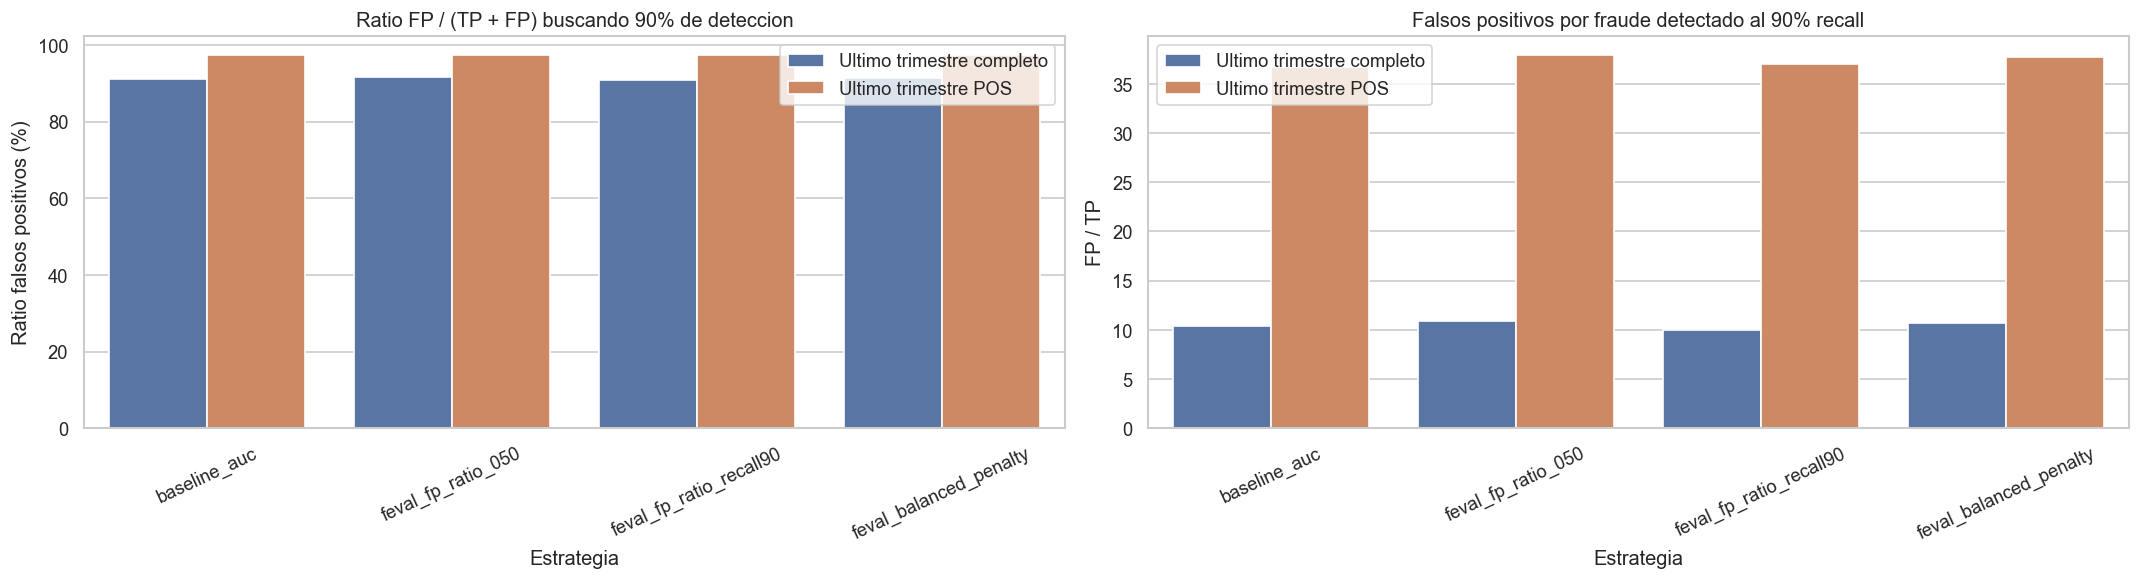

In [10]:
plot_custom = custom_comparison_df.copy()
plot_custom['segment'] = plot_custom['segment'].map({
    'ultimo_trimestre_todas': 'Ultimo trimestre completo',
    'ultimo_trimestre_pos_presencial': 'Ultimo trimestre POS',
})

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(
    data=plot_custom,
    x='strategy',
    y='fp_ratio_recall_target_pct',
    hue='segment',
    ax=axes[0],
)
axes[0].set_title('Ratio FP / (TP + FP) buscando 90% de deteccion')
axes[0].set_xlabel('Estrategia')
axes[0].set_ylabel('Ratio falsos positivos (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='')

sns.barplot(
    data=plot_custom,
    x='strategy',
    y='fp_per_tp_recall_target',
    hue='segment',
    ax=axes[1],
)
axes[1].set_title('Falsos positivos por fraude detectado al 90% recall')
axes[1].set_xlabel('Estrategia')
axes[1].set_ylabel('FP / TP')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='')

plt.tight_layout()
plt.show()


In [11]:
pos_strategy_ranking = (
    custom_comparison_df.query("segment == 'ultimo_trimestre_pos_presencial'")
    .sort_values(['fp_ratio_recall_target_pct', 'fp_recall_target', 'threshold_recall_target'], ascending=[True, True, False])
    .reset_index(drop=True)
)

best_custom_strategy = pos_strategy_ranking.iloc[0]
display(pos_strategy_ranking[[
    'strategy', 'threshold_recall_target', 'tp_recall_target', 'fp_recall_target',
    'recall_recall_target_pct', 'precision_recall_target_pct', 'fp_ratio_recall_target_pct', 'fp_per_tp_recall_target'
]].round(4))

print('Mejor estrategia para compras presenciales segun FP/(TP+FP) con 90% recall:')
print(best_custom_strategy['strategy'])


,strategy,threshold_recall_target,tp_recall_target,fp_recall_target,recall_recall_target_pct,precision_recall_target_pct,fp_ratio_recall_target_pct,fp_per_tp_recall_target
0,baseline_auc,0.0606,385,14120,90.1639,2.6543,97.3457,36.6753
1,feval_fp_ratio_recall90,0.0970,385,14244,90.1639,2.6318,97.3682,36.9974
2,feval_balanced_penalty,0.0924,385,14528,90.1639,2.5816,97.4184,37.7351
3,feval_fp_ratio_050,0.0855,385,14613,90.1639,2.5670,97.4330,37.9558


Mejor estrategia para compras presenciales segun FP/(TP+FP) con 90% recall:
baseline_auc


Resultado de la comparacion custom
La mejor estrategia para compras presenciales, usando el criterio FP / (TP + FP) y buscando al menos 90% de deteccion, fue baseline_auc.

Con esta estrategia se detectaron 385 fraudes presenciales y se generaron 14120 falsos positivos. La deteccion alcanzada fue 90.16%, con precision de alertas de 2.65% y ratio de falsos positivos de 97.35%.

Este resultado muestra que exigir 90% de deteccion en compras presenciales es muy costoso en falsos positivos. Por eso, la siguiente iteracion deberia explorar metricas custom y umbrales que reduzcan alertas falsas sin forzar un recall tan alto cuando el segmento POS tiene baja prevalencia de fraude.

### Interpretacion de las metricas custom

La comparacion debe leerse desde el segmento de compras presenciales, porque ese es el foco del objetivo asignado. La estrategia ganadora sera la que, manteniendo aproximadamente `90%` de deteccion de fraude, produzca el menor `FP / (TP + FP)`. Si dos estrategias tienen una ratio similar, se prefiere la que genere menos falsos positivos absolutos y un threshold mas estable.

## 6) Fraude detectado y falsos positivos

Ademas de AUC y F1, se reportan conteos operativos: verdaderos positivos, falsos positivos y la proporcion de alertas que resultan falsas (`FP / (TP + FP)`).

In [13]:
def operational_metrics(y_true, proba, threshold=0.50, label='test'):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    alerts = tp + fp
    return {
        'subset': label,
        'threshold': threshold,
        'transacciones': int(len(y_true)),
        'fraudes_reales': int(y_true.sum()),
        'fraudes_detectados_tp': int(tp),
        'fraudes_no_detectados_fn': int(fn),
        'falsos_positivos_fp': int(fp),
        'verdaderos_negativos_tn': int(tn),
        'alertas_totales_tp_fp': int(alerts),
        'fraude_detectado_recall_pct': recall_score(y_true, pred, zero_division=0) * 100,
        'precision_alertas_pct': precision_score(y_true, pred, zero_division=0) * 100,
        'ratio_falsos_positivos_pct': (fp / alerts * 100) if alerts else 0,
        'fp_por_fraude_detectado': (fp / tp) if tp else np.inf,
        'f1': f1_score(y_true, pred, zero_division=0),
        'auc_roc': roc_auc_score(y_true, proba) if len(np.unique(y_true)) == 2 else np.nan,
    }

test_pos_mask_local = pos_eval_mask.loc[test_mask].to_numpy()

ops_rows = [
    operational_metrics(y_test.to_numpy(), y_test_proba, default_threshold, 'test_junio_todas'),
    operational_metrics(y_test.loc[test_pos_mask_local].to_numpy(), y_test_proba[test_pos_mask_local], default_threshold, 'test_junio_pos_presencial'),
]

ops_df = pd.DataFrame(ops_rows)
display(ops_df.round(4))


,subset,threshold,transacciones,fraudes_reales,fraudes_detectados_tp,fraudes_no_detectados_fn,falsos_positivos_fp,verdaderos_negativos_tn,alertas_totales_tp_fp,fraude_detectado_recall_pct,precision_alertas_pct,ratio_falsos_positivos_pct,fp_por_fraude_detectado,f1,auc_roc
0,test_junio_todas,0.5,16186,736,571,165,113,15337,684,77.5815,83.4795,16.5205,0.1979,0.8042,0.9069
1,test_junio_pos_presencial,0.5,6440,149,74,75,13,6278,87,49.6644,85.0575,14.9425,0.1757,0.6271,0.7902


### Lectura operativa con threshold 0.50

Con el umbral base de `0.50`, el modelo detecta la mayor parte del fraude en el test completo, pero todavia genera alertas falsas. En compras presenciales el ratio de falsos positivos es menor, aunque el recall baja: esto indica que el modelo es mas conservador en POS y deja pasar mas fraude presencial. Esta tension entre detectar fraude y reducir falsos positivos es el punto de partida para las metricas custom.

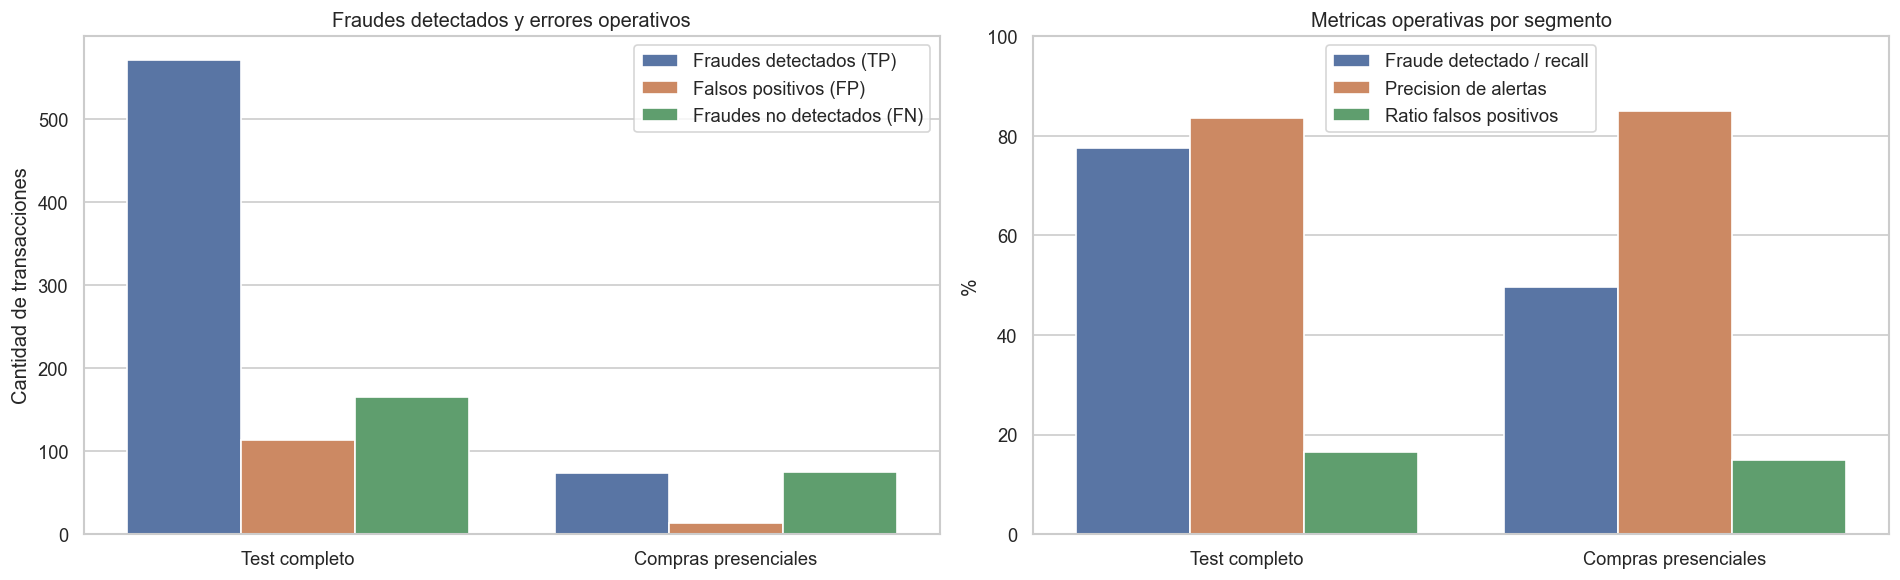

In [14]:
plot_ops = ops_df.melt(
    id_vars='subset',
    value_vars=['fraudes_detectados_tp', 'falsos_positivos_fp', 'fraudes_no_detectados_fn'],
    var_name='tipo',
    value_name='cantidad',
)

label_map = {
    'fraudes_detectados_tp': 'Fraudes detectados (TP)',
    'falsos_positivos_fp': 'Falsos positivos (FP)',
    'fraudes_no_detectados_fn': 'Fraudes no detectados (FN)',
}
plot_ops['tipo'] = plot_ops['tipo'].map(label_map)
plot_ops['subset'] = plot_ops['subset'].map({
    'test_junio_todas': 'Test completo',
    'test_junio_pos_presencial': 'Compras presenciales',
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_ops, x='subset', y='cantidad', hue='tipo', ax=axes[0])
axes[0].set_title('Fraudes detectados y errores operativos')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de transacciones')
axes[0].legend(title='')

rate_cols = ['fraude_detectado_recall_pct', 'precision_alertas_pct', 'ratio_falsos_positivos_pct']
plot_rates = ops_df[['subset'] + rate_cols].copy()
plot_rates['subset'] = plot_rates['subset'].map({
    'test_junio_todas': 'Test completo',
    'test_junio_pos_presencial': 'Compras presenciales',
})
plot_rates = plot_rates.melt(id_vars='subset', value_vars=rate_cols, var_name='metrica', value_name='porcentaje')
plot_rates['metrica'] = plot_rates['metrica'].map({
    'fraude_detectado_recall_pct': 'Fraude detectado / recall',
    'precision_alertas_pct': 'Precision de alertas',
    'ratio_falsos_positivos_pct': 'Ratio falsos positivos',
})

sns.barplot(data=plot_rates, x='subset', y='porcentaje', hue='metrica', ax=axes[1])
axes[1].set_title('Metricas operativas por segmento')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].legend(title='')

plt.tight_layout()
plt.show()


### Distribucion de scores

La distribucion de probabilidades permite ver si el modelo separa bien transacciones legitimas y fraudulentas. Cuando las curvas se solapan cerca del threshold, subir o bajar el umbral cambia directamente los falsos positivos y los fraudes no detectados.

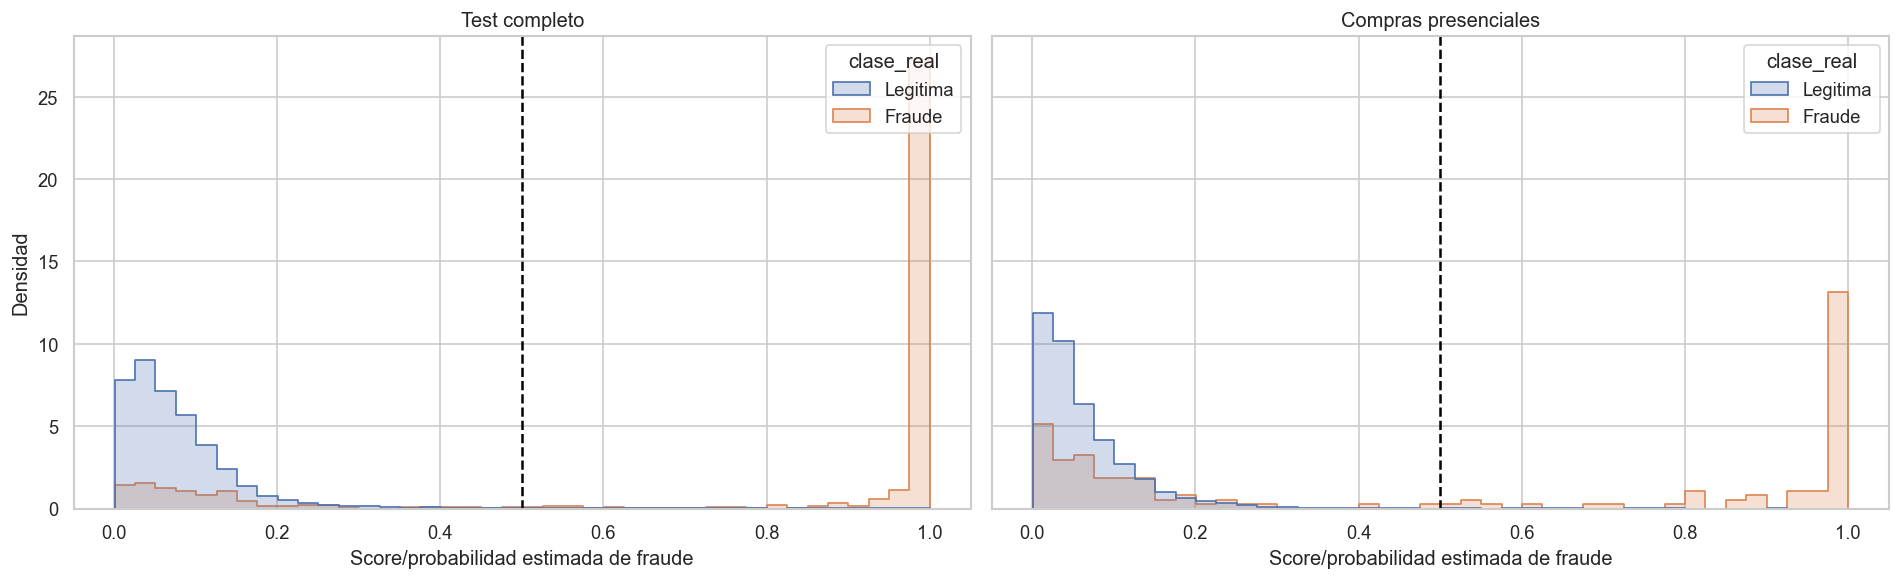

In [15]:
score_df = pd.DataFrame({
    'score_fraude': y_test_proba,
    'clase_real': np.where(y_test.to_numpy() == 1, 'Fraude', 'Legitima'),
    'compra_presencial': test_pos_mask_local,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, mask, title in [
    (axes[0], np.ones(len(score_df), dtype=bool), 'Test completo'),
    (axes[1], score_df['compra_presencial'].to_numpy(), 'Compras presenciales'),
]:
    sns.histplot(
        data=score_df.loc[mask],
        x='score_fraude',
        hue='clase_real',
        bins=40,
        stat='density',
        common_norm=False,
        element='step',
        ax=ax,
    )
    ax.axvline(default_threshold, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.50')
    ax.set_title(title)
    ax.set_xlabel('Score/probabilidad estimada de fraude')
    ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()


## 7) Curvas y matriz de confusion

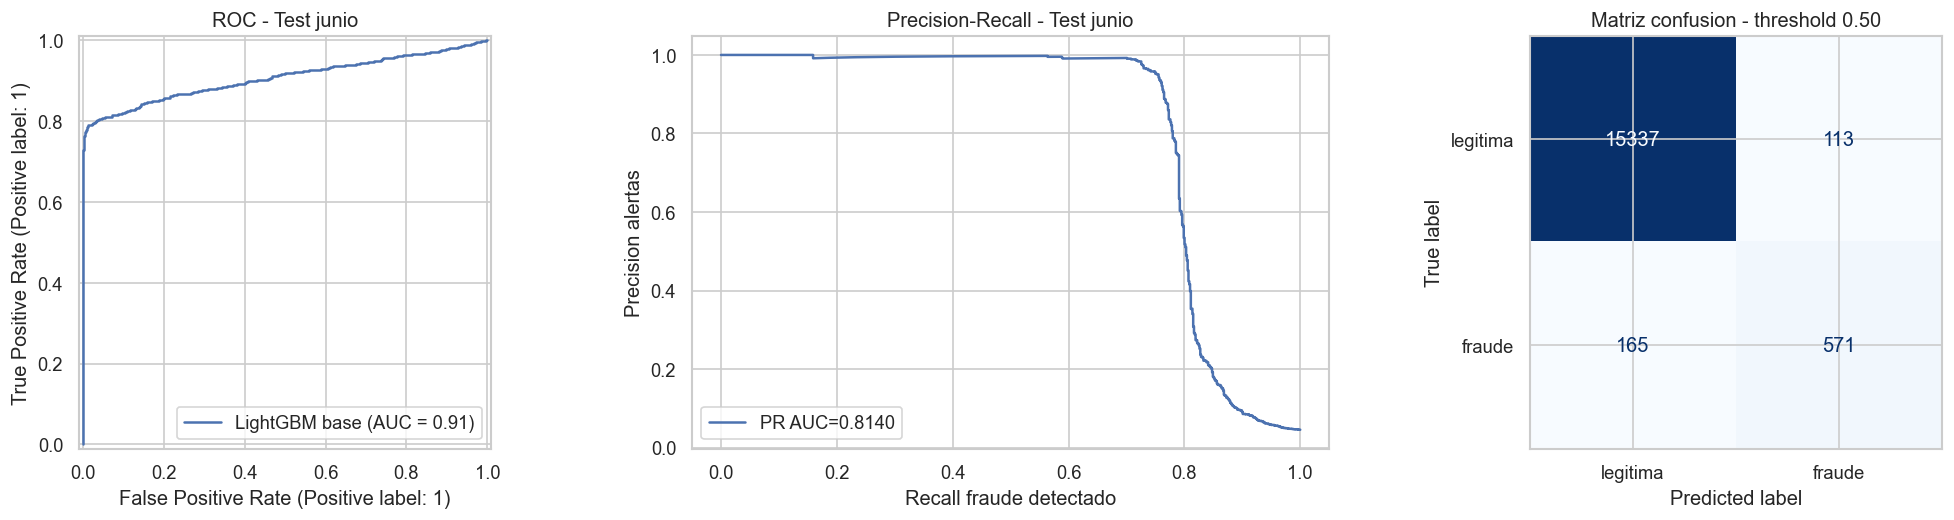

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[0], name='LightGBM base')
axes[0].set_title('ROC - Test junio')

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, label=f'PR AUC={pr_auc:.4f}')
axes[1].set_title('Precision-Recall - Test junio')
axes[1].set_xlabel('Recall fraude detectado')
axes[1].set_ylabel('Precision alertas')
axes[1].legend(loc='best')

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['legitima', 'fraude'], cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title('Matriz confusion - threshold 0.50')

plt.tight_layout()
plt.show()


## 8) Revision de umbrales

El modelo base se reporta con `threshold=0.50`, pero esta tabla muestra el trade-off operativo entre fraude detectado y falsos positivos para preparar la siguiente etapa de metricas custom.

,threshold,fraudes_detectados_tp,falsos_positivos_fp,alertas_totales_tp_fp,fraude_detectado_recall_pct,precision_alertas_pct,ratio_falsos_positivos_pct,fp_por_fraude_detectado,f1
0,0.10,639,4073,4712,86.8207,13.5611,86.4389,6.3740,0.2346
1,0.15,605,1625,2230,82.2011,27.1300,72.8700,2.6860,0.4080
2,0.20,594,787,1381,80.7065,43.0123,56.9877,1.3249,0.5612
3,0.25,588,455,1043,79.8913,56.3758,43.6242,0.7738,0.6610
4,0.30,582,311,893,79.0761,65.1736,34.8264,0.5344,0.7145
5,0.35,582,216,798,79.0761,72.9323,27.0677,0.3711,0.7588
6,0.40,578,172,750,78.5326,77.0667,22.9333,0.2976,0.7779
7,0.45,574,146,720,77.9891,79.7222,20.2778,0.2544,0.7885
8,0.50,571,113,684,77.5815,83.4795,16.5205,0.1979,0.8042
9,0.55,566,79,645,76.9022,87.7519,12.2481,0.1396,0.8197


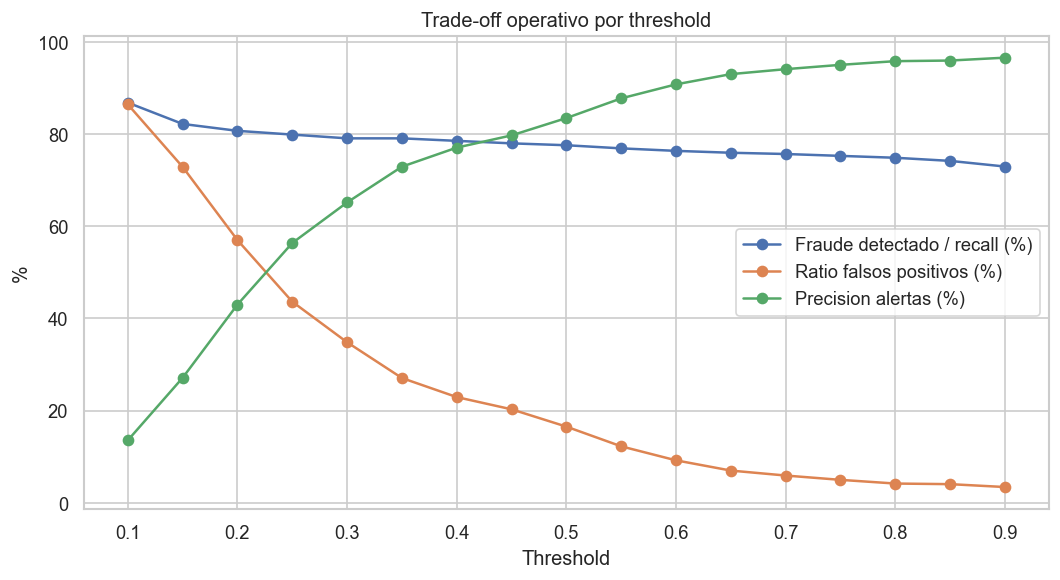

In [17]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_rows = [operational_metrics(y_test.to_numpy(), y_test_proba, float(t), 'test_junio_todas') for t in thresholds]
threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df[[
    'threshold', 'fraudes_detectados_tp', 'falsos_positivos_fp', 'alertas_totales_tp_fp',
    'fraude_detectado_recall_pct', 'precision_alertas_pct', 'ratio_falsos_positivos_pct', 'fp_por_fraude_detectado', 'f1'
]].round(4))

plt.figure(figsize=(9, 5))
plt.plot(threshold_df['threshold'], threshold_df['fraude_detectado_recall_pct'], marker='o', label='Fraude detectado / recall (%)')
plt.plot(threshold_df['threshold'], threshold_df['ratio_falsos_positivos_pct'], marker='o', label='Ratio falsos positivos (%)')
plt.plot(threshold_df['threshold'], threshold_df['precision_alertas_pct'], marker='o', label='Precision alertas (%)')
plt.xlabel('Threshold')
plt.ylabel('%')
plt.title('Trade-off operativo por threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## 9) Importancia de variables

,feature,importance
56,num__DE18_merchant_category_code_fraud_rate_pr...,771
33,num__amount_vs_mcc_mean_prev,676
35,num__time_since_last_txn_min,629
24,num__amount_vs_client_baseline,523
57,num__DE22_pos_entry_mode_fraud_rate_prev_smooth,485
59,num__currency_tx_alpha_fraud_rate_prev_smooth,482
29,num__client_amount_std_prev,461
3,num__client_baseline_amount,458
27,num__client_amount_mean_prev,422
54,num__channel_fraud_rate_prev_smooth,417


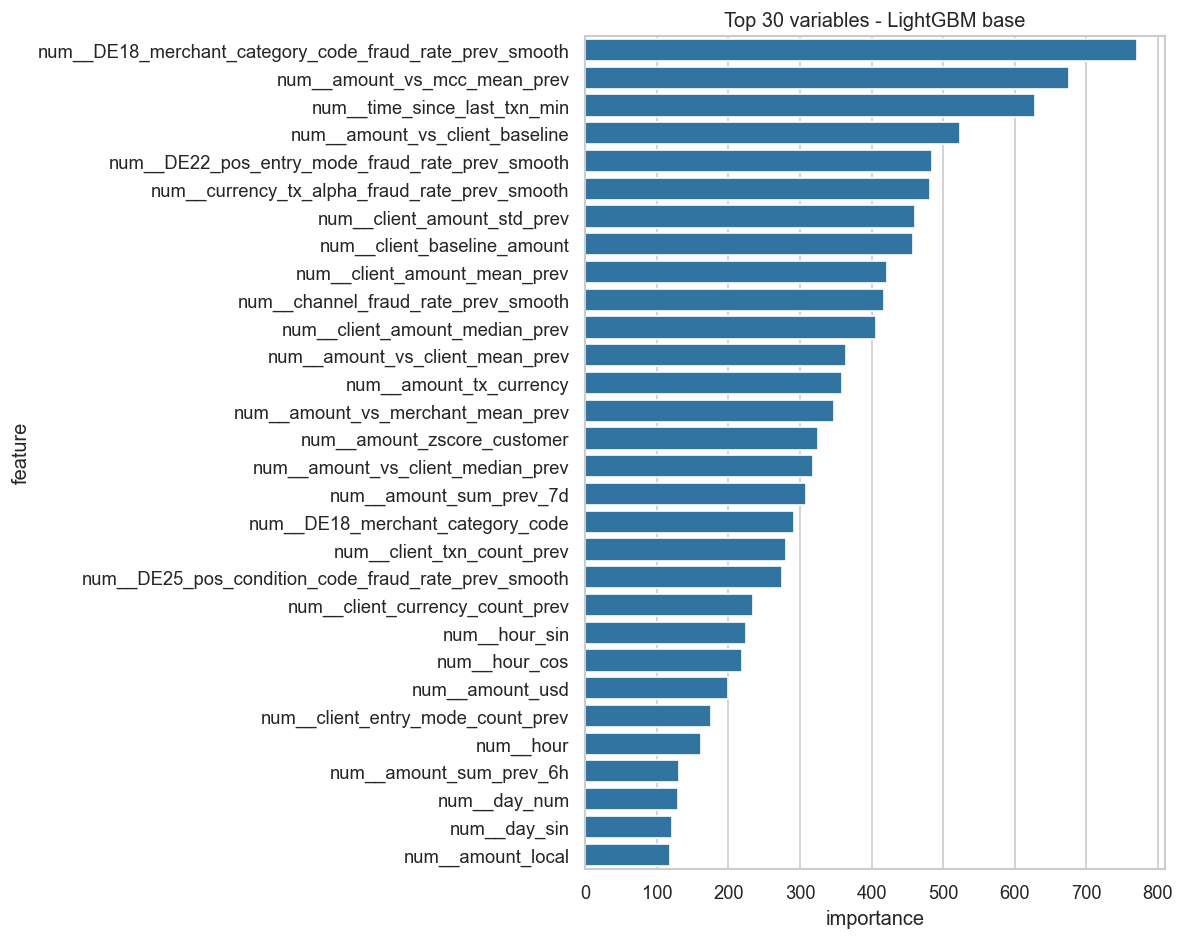

In [18]:
feature_names = clf.named_steps['preprocess'].get_feature_names_out()
importances = clf.named_steps['model'].feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(30)
)

display(importance_df)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature', color='#1f77b4')
plt.title('Top 30 variables - LightGBM base')
plt.tight_layout()
plt.show()


## 10) Lectura inicial de resultados

Con `threshold = 0.50`, el modelo base obtiene `AUC-ROC = 0.9069` y `F1 = 0.8042` en el test completo. Esto indica una buena capacidad general para ordenar transacciones por riesgo y un desempeno inicial razonable para la clase fraude.

En el test completo hay `736` fraudes reales: el modelo detecta `571` y deja sin detectar `165`. A cambio, genera `113` falsos positivos sobre `684` alertas totales, equivalente a un ratio de falsos positivos de `16.52%`.

En compras presenciales, el comportamiento cambia: hay `149` fraudes reales, de los cuales se detectan `74`; se generan solo `13` falsos positivos y el ratio de falsos positivos baja a `14.94%`. Sin embargo, el recall presencial queda en `49.66%`, por lo que el modelo base es relativamente preciso en POS, pero todavia pierde cerca de la mitad de los fraudes presenciales.

Para el Objetivo A, este baseline sirve como punto de comparacion: las siguientes metricas custom deberian buscar reducir el ratio `FP / (TP + FP)` en compras presenciales sin deteriorar demasiado el fraude detectado.